In [1]:
import torch 
import torch.nn as nn

In [2]:
x = torch.rand(size=(8 , 3 , 32 , 32))

print(torch.cuda.is_available())

True


In [3]:
conv = nn.Conv2d(
    in_channels=3,   ## (32 , 32 , 3) p=1 , s=1 , f= 3 , (32-3+2)/1+1 == 32 output --
    out_channels=16,
    kernel_size=3,
    stride=1,
    padding=1
)
output = conv(x)

In [4]:
pool = nn.MaxPool2d(kernel_size=2 , stride=2)

x = torch.randn(size=(8 , 16 , 32 , 32))

output =pool(x)
output.shape

torch.Size([8, 16, 16, 16])

In [5]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(in_features=32 * 8 * 8, out_features=128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)          # 32x32 -> 16x16

        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)          # 16x16 -> 8x8

        x = x.view(x.size(0), -1)  # flatten to (batch, 32*8*8)

        x = self.fc1(x)
        x = F.relu(x)

        x = self.fc2(x)

        return x

In [6]:
import torchvision
import torchvision.transforms as transforms

In [7]:
transforms = transforms.Compose(
    [
        transforms.Resize((32 , 32)),
        transforms.ToTensor()
    ]
)

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform =transforms
)

test_data = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform =transforms
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 56.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.77MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.19MB/s]


In [8]:
from torch.utils.data import DataLoader, Dataset

train_loader = DataLoader(
    train_dataset ,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_data ,
    batch_size=64,
    shuffle=False
)

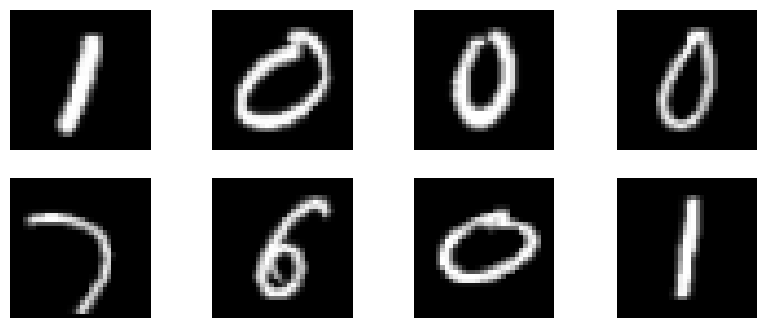

In [9]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))

for i in range(8):
    current_image = images[i].squeeze(0)

    plt.subplot(2, 4, i + 1)
    plt.imshow(current_image, cmap="gray")
    plt.axis("off")

plt.show()


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for image, labels in train_loader:
        image = image.to(device)
        labels = labels.to(device)

        logits = model(image)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predictions = torch.argmax(logits, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    average_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch + 1}, Loss: {average_loss:.4f}, Train accuracy: {train_acc:.4f}")

Epoch 1, Loss: 0.2343, Train accuracy: 0.9289
Epoch 2, Loss: 0.0620, Train accuracy: 0.9813
Epoch 3, Loss: 0.0438, Train accuracy: 0.9868
Epoch 4, Loss: 0.0335, Train accuracy: 0.9891
Epoch 5, Loss: 0.0258, Train accuracy: 0.9916


In [11]:
model.eval()

correct=0
total=0

with torch.no_grad():
    for image , labels in test_loader:
        image = image.to(device)
        labels = labels.to(device)

        logists= model(image)
        loss = criterion(logists , labels)
        prediction = torch.argmax(logists , dim=1)

        correct += (prediction ==labels).sum().item()
        total += len(labels)

print(f" the total predictions correct on test {correct/total}")



 the total predictions correct on test 0.9903


In [12]:
## Important Libaries for Pytroch is torchvision  ['torchvision']
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

In [13]:
### aaj ye concept  kar lunga

#Setup Training data

train_dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None
)

test_dataset=datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None
)


100%|██████████| 26.4M/26.4M [00:01<00:00, 17.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 302kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.63MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.14MB/s]


In [14]:
len(train_dataset) , len(test_data)

(60000, 10000)

In [15]:
class_name = train_dataset.classes
class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [16]:
train_dataset.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [17]:
image , label = train_dataset[0]
print(f"Image shape :{image.shape} --> [color_channels , height , width]")
print(f"Image label : {class_name[label]}")

Image shape :torch.Size([1, 28, 28]) --> [color_channels , height , width]
Image label : Ankle boot


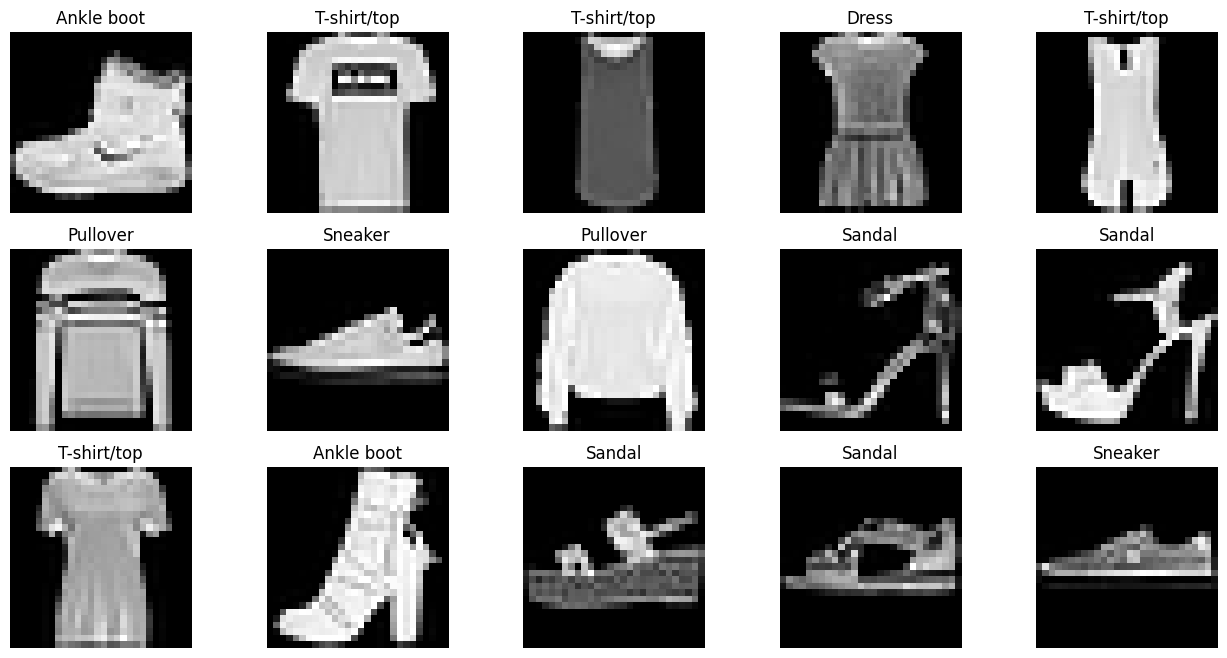

In [18]:
## Grayscale have only one color channel

plt.figure(figsize=(16 , 8))

for i in range(15):
    image , label = train_dataset[i]

    plt.subplot(3 , 5 , i+1)
    plt.imshow(image.squeeze() , cmap='grey')
    plt.title(class_name[label])
    plt.axis("off")

plt.show()

In [19]:
## item of clotthing (image) need non-Linear model. Prepare data model 
test_data , train_dataset

(Dataset MNIST
     Number of datapoints: 10000
     Root location: ./data
     Split: Test
     StandardTransform
 Transform: Compose(
                Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ),
 Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor())

In [20]:
batch_size=32

train_dataloader = DataLoader(dataset= train_dataset , batch_size =32 , shuffle=True)
test_dataloader = DataLoader(dataset=test_dataset , batch_size=32 , shuffle=False)

train_dataloader , test_dataloader


(<torch.utils.data.dataloader.DataLoader at 0x7fdeb664dbd0>,
 <torch.utils.data.dataloader.DataLoader at 0x7fdeb6fd6ea0>)

In [21]:
# Let's check out what we've created
print(f"DataLoaders : {train_dataloader , test_dataloader}")
print(f"Lenght of train_dataLoader : {len(train_dataloader)} batches of {32}")

DataLoaders : (<torch.utils.data.dataloader.DataLoader object at 0x7fdeb664dbd0>, <torch.utils.data.dataloader.DataLoader object at 0x7fdeb6fd6ea0>)
Lenght of train_dataLoader : 1875 batches of 32


In [22]:
train_feature_batch , train_labels_batch = next(iter(train_dataloader))
train_feature_batch.shape , train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [23]:

class FashionMNISTModelCNN(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        # Block 1: conv -> relu -> maxpool
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units,
                      kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)   # 28x28 -> 14x14
        )

        # Block 2: conv -> relu -> maxpool
        self.block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                      kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)   # 14x14 -> 7x7
        )

        # Fully connected classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 7 * 7, out_features=output_shape)
        )

    def forward(self, x):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)
        return x


# Instance


FashionMNISTModelCNN(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)


In [35]:
torch.manual_seed(42)
model_0 = FashionMNISTModelCNN(input_shape=1, hidden_units=10, output_shape=10).to(device)

model_0

FashionMNISTModelCNN(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [36]:
dummy_x = torch.rand([1, 1, 28, 28], device=device)
model_0(dummy_x)

tensor([[ 0.0319, -0.0213, -0.1047,  0.0088,  0.0196, -0.0665, -0.0357,  0.0860,
          0.0903,  0.1344]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [37]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(), lr=0.01)

In [38]:
epochs = 4

for epoch in range(epochs):
    model_0.train()
    train_loss = 0.0
    total = 0
    correct = 0

    for image, label in train_dataloader:
        image = image.to(device)
        label = label.to(device)

        logits = model_0(image)
        loss = criterion(logits, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * image.shape[0]

        prediction = torch.argmax(logits, dim=1)
        correct += (prediction == label).sum().item()
        total += label.size(0)

    train_loss /= total

    print(f"Epoch {epoch+1}: train_loss = {train_loss:.4f}")
    print(f"Accuracy = {correct/total:.4f}")


model_0.eval()
total = 0
correct = 0
with torch.no_grad():
    for image, label in test_dataloader:
        image = image.to(device)
        label = label.to(device)

        logits = model_0(image)
        prediction = torch.argmax(logits, dim=1)
        correct += (prediction == label).sum().item()
        total += label.size(0)

print(f"Test accuracy: {correct/total:.4f}")

Epoch 1: train_loss = 0.4458
Accuracy = 0.8386
Epoch 2: train_loss = 0.3522
Accuracy = 0.8719
Epoch 3: train_loss = 0.3384
Accuracy = 0.8772
Epoch 4: train_loss = 0.3288
Accuracy = 0.8811
Test accuracy: 0.8747


In [43]:


class FashionMNISTModelCNN(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        # Block 1: conv -> batchnorm -> relu -> maxpool
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units,
                      kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)   # 28x28 -> 14x14
        )

        # Block 2: conv -> batchnorm -> relu -> maxpool
        self.block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                      kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)   # 14x14 -> 7x7
        )

        # Fully connected classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 7 * 7, out_features=output_shape)
        )

    def forward(self, x):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)
        return x

# Instance
model_1 = FashionMNISTModelCNN(input_shape=1, hidden_units=10, output_shape=10).to(device)

In [47]:
epochs = 10

for epoch in range(epochs):
    model_1.train()
    train_loss = 0.0
    total = 0
    correct = 0

    for image, label in train_dataloader:
        image = image.to(device)
        label = label.to(device)

        logits = model_1(image)
        loss = criterion(logits, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * image.shape[0]

        prediction = torch.argmax(logits, dim=1)
        correct += (prediction == label).sum().item()
        total += label.size(0)

    train_loss /= total

    print(f"Epoch {epoch+1}: train_loss = {train_loss:.4f}")
    print(f"Accuracy = {correct/total:.4f}")


model_1.eval()
total = 0
correct = 0

num_classes = 10
class_correct = torch.zeros(num_classes)
class_total = torch.zeros(num_classes)

with torch.no_grad():
    for image, label in test_dataloader:
        image = image.to(device)
        label = label.to(device)

        logits = model_1(image)
        prediction = torch.argmax(logits, dim=1)
        correct += (prediction == label).sum().item()
        total += label.size(0)

        # per-class tracking
        for c in range(num_classes):
            mask = (label == c)
            class_total[c] += mask.sum().item()
            class_correct[c] += (prediction[mask] == c).sum().item()

print(f"Test accuracy: {correct/total:.4f}")

# per-class accuracy report
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("\nPer-class accuracy:")
class_acc = class_correct / class_total
for i, name in enumerate(class_names):
    print(f"{name:15s}: {class_acc[i]:.4f}  ({int(class_correct[i])}/{int(class_total[i])})")

worst_idx = torch.argmin(class_acc).item()
best_idx = torch.argmax(class_acc).item()
print(f"\nMost problematic class: {class_names[worst_idx]} ({class_acc[worst_idx]:.4f})")
print(f"Best guessed class:     {class_names[best_idx]} ({class_acc[best_idx]:.4f})")

Epoch 1: train_loss = 2.4043
Accuracy = 0.0894
Epoch 2: train_loss = 2.4040
Accuracy = 0.0886
Epoch 3: train_loss = 2.4043
Accuracy = 0.0889
Epoch 4: train_loss = 2.4040
Accuracy = 0.0885
Epoch 5: train_loss = 2.4040
Accuracy = 0.0891
Epoch 6: train_loss = 2.4043
Accuracy = 0.0888
Epoch 7: train_loss = 2.4041
Accuracy = 0.0889
Epoch 8: train_loss = 2.4042
Accuracy = 0.0887
Epoch 9: train_loss = 2.4040
Accuracy = 0.0886
Epoch 10: train_loss = 2.4039
Accuracy = 0.0889
Test accuracy: 0.0897

Per-class accuracy:
T-shirt/top    : 0.0020  (2/1000)
Trouser        : 0.0010  (1/1000)
Pullover       : 0.1630  (163/1000)
Dress          : 0.0000  (0/1000)
Coat           : 0.0040  (4/1000)
Sandal         : 0.0000  (0/1000)
Shirt          : 0.1430  (143/1000)
Sneaker        : 0.0000  (0/1000)
Bag            : 0.5590  (559/1000)
Ankle boot     : 0.0250  (25/1000)

Most problematic class: Dress (0.0000)
Best guessed class:     Bag (0.5590)


Epoch 1: train_loss = 0.2975
Accuracy = 0.8907
Epoch 2: train_loss = 0.2988
Accuracy = 0.8907
Epoch 3: train_loss = 0.2997
Accuracy = 0.8910
Epoch 4: train_loss = 0.2982
Accuracy = 0.8911
Epoch 5: train_loss = 0.2999
Accuracy = 0.8909
Epoch 6: train_loss = 0.2992
Accuracy = 0.8908
Epoch 7: train_loss = 0.2981
Accuracy = 0.8918
Epoch 8: train_loss = 0.2975
Accuracy = 0.8901
Epoch 9: train_loss = 0.2981
Accuracy = 0.8912
Epoch 10: train_loss = 0.2955
Accuracy = 0.8935
Test accuracy: 0.8711

Per-class accuracy:
T-shirt/top    : 0.8100  (810/1000)
Trouser        : 0.9750  (975/1000)
Pullover       : 0.7610  (761/1000)
Dress          : 0.8930  (893/1000)
Coat           : 0.7310  (731/1000)
Sandal         : 0.9520  (952/1000)
Shirt          : 0.6850  (685/1000)
Sneaker        : 0.9780  (978/1000)
Bag            : 0.9790  (979/1000)
Ankle boot     : 0.9470  (947/1000)

Most problematic class: Shirt (0.6850)
Best guessed class:     Bag (0.9790)


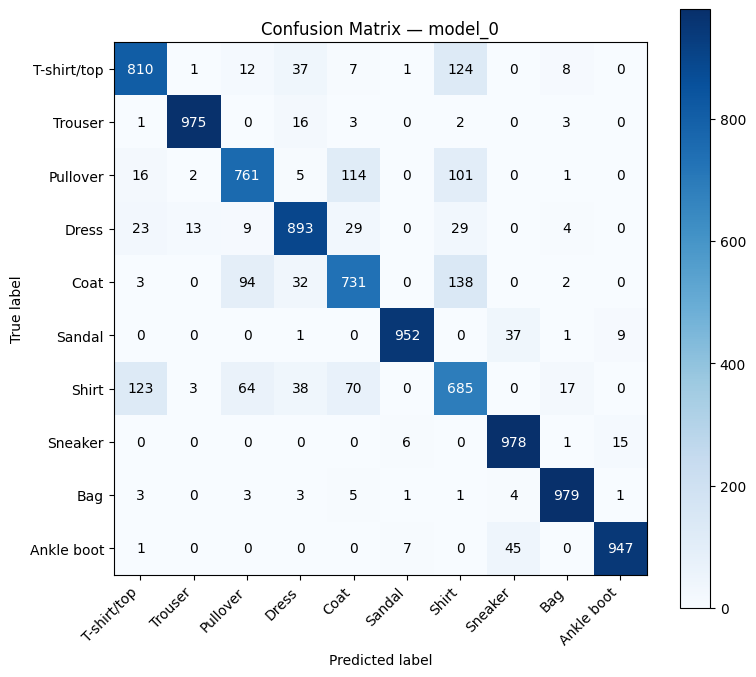

In [49]:
import numpy as np
from sklearn.metrics import confusion_matrix

epochs = 10

for epoch in range(epochs):
    model_0.train()
    train_loss = 0.0
    total = 0
    correct = 0

    for image, label in train_dataloader:
        image = image.to(device)
        label = label.to(device)

        logits = model_0(image)
        loss = criterion(logits, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * image.shape[0]

        prediction = torch.argmax(logits, dim=1)
        correct += (prediction == label).sum().item()
        total += label.size(0)

    train_loss /= total

    print(f"Epoch {epoch+1}: train_loss = {train_loss:.4f}")
    print(f"Accuracy = {correct/total:.4f}")


model_0.eval()
total = 0
correct = 0

num_classes = 10
class_correct = torch.zeros(num_classes)
class_total = torch.zeros(num_classes)

all_preds = []
all_labels = []

with torch.no_grad():
    for image, label in test_dataloader:
        image = image.to(device)
        label = label.to(device)

        logits = model_0(image)
        prediction = torch.argmax(logits, dim=1)
        correct += (prediction == label).sum().item()
        total += label.size(0)

        # per-class tracking
        for c in range(num_classes):
            mask = (label == c)
            class_total[c] += mask.sum().item()
            class_correct[c] += (prediction[mask] == c).sum().item()

        # collect for confusion matrix
        all_preds.extend(prediction.cpu().numpy())
        all_labels.extend(label.cpu().numpy())

print(f"Test accuracy: {correct/total:.4f}")

# per-class accuracy report
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("\nPer-class accuracy:")
class_acc = class_correct / class_total
for i, name in enumerate(class_names):
    print(f"{name:15s}: {class_acc[i]:.4f}  ({int(class_correct[i])}/{int(class_total[i])})")

worst_idx = torch.argmin(class_acc).item()
best_idx = torch.argmax(class_acc).item()
print(f"\nMost problematic class: {class_names[worst_idx]} ({class_acc[worst_idx]:.4f})")
print(f"Best guessed class:     {class_names[best_idx]} ({class_acc[best_idx]:.4f})")

# ----- Confusion matrix heatmap -----
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(10), class_names, rotation=45, ha='right')
plt.yticks(range(10), class_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix — model_0')

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                  color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()